# Module 2 – Placement Prediction: Step-by-Step Preprocessing

### Topics covered
1. Train/Test Split
2. Missing-value analysis
3. Median imputation
4. Missing-indicator features
5. Label encoding of the target
6. Ordinal encoding of ordered features
7. One-hot encoding of nominal features
8. Feature scaling

**Important:** This notebook intentionally does **not** use `Pipeline` or `ColumnTransformer`.

The purpose is to let beginners see every preprocessing operation separately.

### Correct order

```text
Load Data
    ↓
Remove Duplicates
    ↓
Separate X and y
    ↓
Train/Test Split
    ↓
Missing Value Handling
    ↓
Categorical Encoding
    ↓
Feature Scaling
    ↓
ML Model
    ↓
Evaluation
```

**Golden rule:** Fit/learn every preprocessing rule using training data only. Then apply the learned rule to the test data.


In [ ]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. LOAD THE PLACEMENTPREDICT DATASET

The slides use the PlacementPredict student placement dataset.

If your CSV is stored in another location, change only the path below.


In [ ]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv(
    r'C:\\Users\\vippa\\OneDrive\\Desktop\\KLH\\ML\\Placement Prediction\\data\\Prediction.csv'
)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


## 3. BASIC DATASET UNDERSTANDING

Before preprocessing, check the number of rows, columns, data types and duplicate records.


In [3]:
# ============================================================
# 3. BASIC INSPECTION
# ============================================================

print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nDuplicate rows:", df.duplicated().sum())


Shape: (50000, 32)

Data types:
StudentID               int64
Gender                    str
City                      str
CollegeTier               str
Stream                    str
Specialisation            str
Hostel                    str
HistoryOfBacklogs         str
SGPA_Sem1             float64
SGPA_Sem2             float64
SGPA_Sem3             float64
SGPA_Sem4             float64
SGPA_Sem5             float64
SGPA_Sem6             float64
SGPA_Sem7             float64
SGPA_Sem8             float64
CGPA                  float64
AttendancePercent     float64
Internships             int64
Projects                int64
Workshops             float64
Certifications          int64
Publications            int64
AptitudeTestScore     float64
SoftSkillsRating      float64
CodingTestScore       float64
MockInterviewScore    float64
ExtraCurricular         int64
CGPA_Tier                 str
PlacementStatus         int64
IsAnomaly               int64
Salary Package        float64
dtype: o

## 4. REMOVE DUPLICATE ROWS

Duplicate records can give the same student information more influence during model training.

We remove exact duplicate rows before creating the train/test sets.


In [4]:
# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================

rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)

print("Rows before removing duplicates:", rows_before)
print("Rows after removing duplicates :", rows_after)
print("Duplicates removed             :", rows_before - rows_after)


Rows before removing duplicates: 50000
Rows after removing duplicates : 50000
Duplicates removed             : 0


## 5. SEPARATE FEATURES (X) AND TARGET (y)

`X` contains the input features.

`y` contains the value that we want to predict.

For this dataset, the target is `PlacementStatus`.

The target must **not** be imputed or scaled as an input feature.


In [5]:
# ============================================================
# 5. SEPARATE X AND y
# ============================================================

X = df.drop("PlacementStatus", axis=1)
y = df["PlacementStatus"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())


X shape: (50000, 31)
y shape: (50000,)

Target distribution:
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64


# 6. TRAIN/TEST SPLIT — BEFORE PREPROCESSING

This step must come **before** imputation, encoding and scaling.

Why?

Because the test set represents unseen future data.

We must not use test data to calculate:

- median values
- category mappings
- means
- standard deviations
- minimum/maximum values

This prevents **data leakage**.


In [6]:
# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))
print("Training percentage:", len(X_train) / len(X) * 100)
print("Testing percentage :", len(X_test) / len(X) * 100)


Training rows: 40000
Testing rows : 10000
Training percentage: 80.0
Testing percentage : 20.0


# 7. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES

We separate the columns because different types of data need different preprocessing.

**Numerical features:** CGPA, attendance, internships, etc.

**Categorical features:** Gender, City, Stream, Specialisation, etc.


In [7]:
# ============================================================
# 7. IDENTIFY COLUMN TYPES
# ============================================================

numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)


Numerical columns: 23
['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'IsAnomaly', 'Salary Package']

Categorical columns: 8
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']


# 8. MISSING-VALUE AUDIT

The slides identify five important PlacementPredict features with missing values:

- `MockInterviewScore`
- `Workshops`
- `AptitudeTestScore`
- `SoftSkillsRating`
- `CodingTestScore`

We calculate missingness using **X_train only**.


In [8]:
# ============================================================
# 8. MISSING VALUE ANALYSIS
# ============================================================

missing_count = X_train.isna().sum()
missing_percent = X_train.isna().mean() * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing %", ascending=False)

display(missing_summary)


,Missing Count,Missing %
MockInterviewScore,3932,9.8300
Workshops,3577,8.9425
AptitudeTestScore,3196,7.9900
SoftSkillsRating,2840,7.1000
CodingTestScore,2383,5.9575


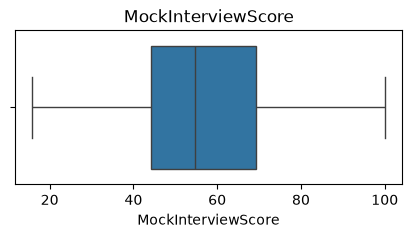

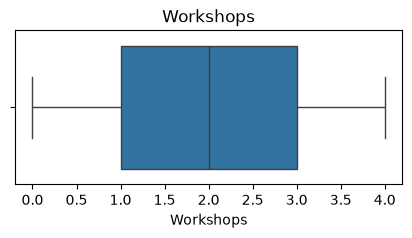

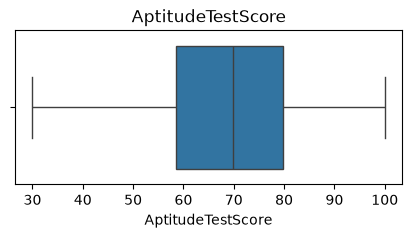

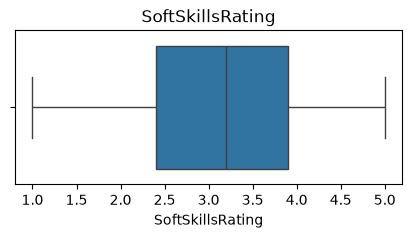

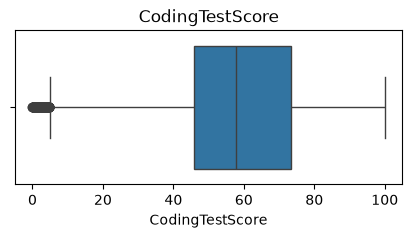

In [38]:
missing_cols=missing_summary.index.tolist()
for col in missing_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[missing_cols][col])
    plt.title(col)
    plt.show()

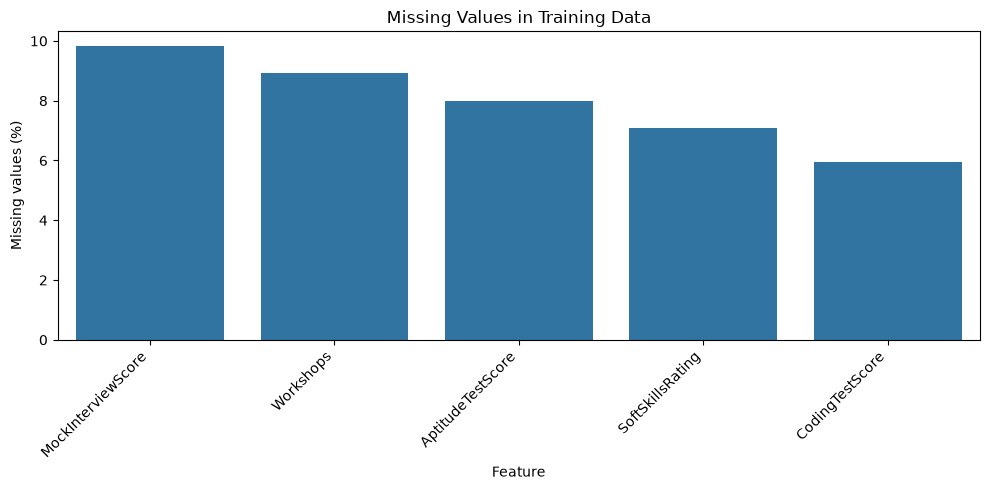

In [9]:
# ============================================================
# 8A. MISSING-VALUE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_summary.index,
    y=missing_summary["Missing %"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Feature")
plt.ylabel("Missing values (%)")
plt.title("Missing Values in Training Data")
plt.tight_layout()
plt.show()


# 9. CHECK THE EFFECT OF ROW DELETION

Before choosing deletion, measure how many training rows would be lost.

If a large percentage of students are removed, imputation is usually preferable.

The slides show that listwise deletion can result in substantial data loss for this dataset.

## NOTE: We are not deleting actually 

In [10]:
# ============================================================
# 9. LISTWISE DELETION CHECK
# ============================================================

rows_before = len(X_train)

X_train_without_missing = X_train.dropna()

rows_after = len(X_train_without_missing)

loss = rows_before - rows_after
loss_percent = loss / rows_before * 100

print("Rows before deletion:", rows_before)
print("Rows after deletion :", rows_after)
print("Rows lost           :", loss)
print("Percentage lost     :", round(loss_percent, 2), "%")


Rows before deletion: 40000
Rows after deletion : 26360
Rows lost           : 13640
Percentage lost     : 34.1 %


In [11]:
X_train.shape

(40000, 31)

# 10. MEDIAN IMPUTATION FOR NUMERICAL FEATURES

For numerical missing values, the slides discuss mean and median imputation.

We use **median imputation** in the main workflow because the median is less affected by outliers and skewed values.

### Important

We calculate the median using **X_train only**.

Then we use those same medians for X_test.

We do not calculate a separate median for the test set.


In [12]:
# ============================================================
# 10. MEDIAN IMPUTATION
# ============================================================

# Create the imputer
numeric_imputer = SimpleImputer(strategy="median")

# STEP 1: Learn medians ONLY from training data
X_train_num = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

# STEP 2: Apply the SAME training medians to test data
X_test_num = pd.DataFrame(
    numeric_imputer.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

print("Missing numerical values after imputation:")
print("Training:", X_train_num.isna().sum().sum())
print("Test    :", X_test_num.isna().sum().sum())


Missing numerical values after imputation:
Training: 0
Test    : 0


In [13]:
X_train_num.shape

(40000, 23)

# 11. MISSING-INDICATOR FEATURES

Imputation replaces a missing value, but sometimes the fact that it was missing is itself useful information.

Example:

```text
AptitudeTestScore = missing
```

After imputation:

```text
AptitudeTestScore = median
```

The model may not know that the original value was missing.

A missing indicator preserves that information:

```text
0 → value was originally present
1 → value was originally missing
```


In [ ]:
''' # ============================================================
# 11. MISSING INDICATORS
# ============================================================

missing_numeric_cols = [
    col for col in numeric_cols
    if X_train[col].isna().any()
]

print("Numerical columns with missing values:")
print(missing_numeric_cols)

for col in missing_numeric_cols:
    X_train_num[col + "_missing"] = (
        X_train[col].isna().astype(int)
    )

    X_test_num[col + "_missing"] = (
        X_test[col].isna().astype(int)
    )

print("\nMissing indicators created.") '''


In [14]:
X_train_num

,StudentID,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,...,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,IsAnomaly,Salary Package
23718,23719.0,10.00,9.97,10.00,10.00,9.44,10.00,9.97,10.00,9.88,...,3.0,4.0,1.0,77.9,3.5,65.1,70.4,0.0,0.0,18.72
22324,22325.0,7.17,6.97,6.99,6.93,6.98,6.72,7.09,7.48,6.98,...,1.0,2.0,1.0,68.3,3.4,56.3,53.4,0.0,0.0,8.79
19705,19706.0,8.41,8.52,8.37,7.36,7.94,8.06,7.85,8.22,8.05,...,2.0,3.0,0.0,60.9,2.2,56.6,57.9,0.0,0.0,18.97
19144,19145.0,9.14,9.12,9.17,8.55,9.29,8.83,8.97,9.10,9.01,...,2.0,4.0,2.0,88.8,3.1,68.9,66.3,1.0,0.0,18.23
48425,48426.0,4.90,4.87,5.27,4.34,4.55,4.64,4.25,4.35,4.49,...,0.0,1.0,0.0,67.6,3.3,52.2,55.7,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43700,43701.0,7.52,7.27,7.33,7.29,7.64,7.85,7.20,7.13,7.43,...,1.0,1.0,1.0,74.7,3.6,46.9,46.2,0.0,0.0,8.45
35383,35384.0,7.80,8.01,7.85,8.15,7.77,8.73,8.81,8.43,8.25,...,1.0,3.0,1.0,81.2,4.5,86.7,82.3,1.0,0.0,22.78
33008,33009.0,9.17,8.87,9.37,8.45,9.25,8.84,9.13,9.47,9.10,...,3.0,4.0,2.0,78.4,4.1,78.8,95.3,0.0,0.0,18.35
28804,28805.0,6.31,5.68,5.52,5.86,5.64,5.79,6.47,5.56,5.89,...,0.0,0.0,0.0,45.6,2.0,28.9,32.9,1.0,0.0,0.00


In [15]:
X_train_num.shape

(40000, 23)

# 12. CATEGORICAL FEATURES: ORDINAL VS NOMINAL

The slides distinguish two types.

### Ordinal categorical features

There is a meaningful order.

Example:

```text
Tier 1 < Tier 2 < Tier 3
```

Use **ordinal encoding**.

### Nominal categorical features

There is no meaningful order.

Example:

```text
CSE, ECE, EEE
```

Use **one-hot encoding**.

Do not blindly convert nominal categories into 0, 1, 2 because that can create a false ranking.


In [ ]:
# ============================================================
# 12.A DEFINE ORDINAL AND NOMINAL FEATURES
# ============================================================

# These are the ordinal columns identified in the slides.
ordinal_cols = [
    col for col in ["CollegeTier", "CGPA_Tier"]
    if col in X_train.columns
]

# All remaining categorical columns are treated as nominal.
nominal_cols = [
    col for col in categorical_cols
    if col not in ordinal_cols
]

print("Ordinal columns:")
print(ordinal_cols)

print("\nNominal columns:")
print(nominal_cols)


Ordinal columns:
['CollegeTier', 'CGPA_Tier']

Nominal columns:
['Gender', 'City', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs']


In [18]:
for col in nominal_cols:
    print(f"\n{col}")
    print(X_train[col].unique())


Gender
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

City
<StringArray>
['Ahmedabad',     'Kochi',   'Kolkata',      'Pune', 'Bangalore',     'Delhi',
 'Hyderabad',   'Chennai',    'Mumbai',    'Jaipur']
Length: 10, dtype: str

Stream
<StringArray>
['Civil', 'CS', 'IT', 'ECE', 'Mechanical', 'EE']
Length: 6, dtype: str

Specialisation
<StringArray>
['Embedded', 'DataScience', 'AI', 'Networking']
Length: 4, dtype: str

Hostel
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

HistoryOfBacklogs
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [ ]:

# ============================================================
# 12B. ONE-HOT ENCODING FOR NOMINAL FEATURES
# ============================================================

from sklearn.preprocessing import OneHotEncoder

# Drop the first category of EACH nominal variable.
# This gives K-1 dummy variables for a variable having K categories.
# It helps avoid the dummy-variable trap / perfect multicollinearity.

nominal_encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

# ------------------------------------------------------------
# FIT ON X_train AND TRANSFORM X_train
# ------------------------------------------------------------

nominal_encoded_train = nominal_encoder.fit_transform(
    X_train[nominal_cols]
)

nominal_feature_names = (
    nominal_encoder.get_feature_names_out(nominal_cols)
)

nominal_encoded_train = pd.DataFrame(
    nominal_encoded_train,
    columns=nominal_feature_names,
    index=X_train.index
)

print("\nOne-hot encoded X_train:")
display(nominal_encoded_train.head())

print("\nEncoded nominal feature names:")
print(nominal_feature_names.tolist())

print("\nNumber of nominal features after encoding:",
      nominal_encoded_train.shape[1])


# ------------------------------------------------------------
# TRANSFORM X_test USING THE SAME ENCODER
# ------------------------------------------------------------

nominal_encoded_test = nominal_encoder.transform(
    X_test[nominal_cols]
)

nominal_encoded_test = pd.DataFrame(
    nominal_encoded_test,
    columns=nominal_feature_names,
    index=X_test.index
)

print("\nOne-hot encoded X_test:")
display(nominal_encoded_test.head())

print("\nX_train nominal encoded shape:",
      nominal_encoded_train.shape)

print("X_test nominal encoded shape:",
      nominal_encoded_test.shape)


One-hot encoded X_train:


,Gender_Male,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Jaipur,City_Kochi,City_Kolkata,City_Mumbai,City_Pune,Stream_Civil,Stream_ECE,Stream_EE,Stream_IT,Stream_Mechanical,Specialisation_DataScience,Specialisation_Embedded,Specialisation_Networking,Hostel_Yes,HistoryOfBacklogs_Yes
23718,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
22324,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
19705,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
19144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
48425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0



Encoded nominal feature names:
['Gender_Male', 'City_Bangalore', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kochi', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Stream_Civil', 'Stream_ECE', 'Stream_EE', 'Stream_IT', 'Stream_Mechanical', 'Specialisation_DataScience', 'Specialisation_Embedded', 'Specialisation_Networking', 'Hostel_Yes', 'HistoryOfBacklogs_Yes']

Number of nominal features after encoding: 20

One-hot encoded X_test:


,Gender_Male,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Jaipur,City_Kochi,City_Kolkata,City_Mumbai,City_Pune,Stream_Civil,Stream_ECE,Stream_EE,Stream_IT,Stream_Mechanical,Specialisation_DataScience,Specialisation_Embedded,Specialisation_Networking,Hostel_Yes,HistoryOfBacklogs_Yes
17139,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
7376,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12078,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
26764,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
17802,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0



X_train nominal encoded shape: (40000, 20)
X_test nominal encoded shape: (10000, 20)


In [21]:
nominal_encoded_train.shape

(40000, 20)

# 13. LABEL ENCODING — TARGET

`LabelEncoder` is used here for the **target variable**.

Example:

```text
Not Placed → 0
Placed     → 1
```

We fit the encoder on `y_train` and use the same mapping on `y_test`.

We do not use `LabelEncoder` blindly on nominal input features.



In [ ]:
# ============================================================
# 13. LABEL ENCODE THE TARGET
# ============================================================

label_encoder = LabelEncoder()

# Learn target mapping from training labels
y_train_encoded = label_encoder.fit_transform(y_train)

# Apply the same mapping to test labels
y_test_encoded = label_encoder.transform(y_test)

print("Original target classes:")
print(label_encoder.classes_)

print("\nEncoded target values:")
print(np.unique(y_train_encoded))


Original target classes:
[0 1]

Encoded target values:
[0 1]


# 14. HANDLE MISSING CATEGORICAL VALUES

For categorical columns with missing values, use the most frequent category.

Again, learn the most frequent category from the training data only.


In [ ]:


# ============================================================
# 14. CATEGORICAL IMPUTATION
# ============================================================

# ----- Ordinal columns -----
if ordinal_cols:
    ordinal_imputer = SimpleImputer(strategy="most_frequent")

    X_train_ord = pd.DataFrame(
        ordinal_imputer.fit_transform(X_train[ordinal_cols]),
        columns=ordinal_cols,
        index=X_train.index
    )

    X_test_ord = pd.DataFrame(
        ordinal_imputer.transform(X_test[ordinal_cols]),
        columns=ordinal_cols,
        index=X_test.index
    )
else:
    X_train_ord = pd.DataFrame(index=X_train.index)
    X_test_ord = pd.DataFrame(index=X_test.index)


# ----- Nominal columns -----
if nominal_cols:
    nominal_imputer = SimpleImputer(strategy="most_frequent")

    X_train_nom = pd.DataFrame(
        nominal_imputer.fit_transform(X_train[nominal_cols]),
        columns=nominal_cols,
        index=X_train.index
    )

    X_test_nom = pd.DataFrame(
        nominal_imputer.transform(X_test[nominal_cols]),
        columns=nominal_cols,
        index=X_test.index
    )
else:
    X_train_nom = pd.DataFrame(index=X_train.index)
    X_test_nom = pd.DataFrame(index=X_test.index)

print("Categorical imputation completed.")


Categorical imputation completed.


In [24]:
X_train_num.shape
       

(40000, 23)

In [25]:
X_train_ord.shape       
       

(40000, 2)

In [26]:
nominal_encoded_train.shape

(40000, 20)

# 15. COMBINE THE PREPROCESSED FEATURES

Now combine:

1. Imputed numerical features
3. Ordinal encoded features
3. One-hot encoded features

The target remains separate.



In [ ]:
# ============================================================
# 15. COMBINE FEATURES
# ============================================================

X_train_processed = pd.concat(
    [
        X_train_num,
        X_train_ord,        
        nominal_encoded_train

    ],
    axis=1
)

X_test_processed = pd.concat(
    [
        X_test_num,
        X_test_ord,        
        nominal_encoded_test
    ],
    axis=1
)

print("X_train processed shape:", X_train_processed.shape)
print("X_test processed shape :", X_test_processed.shape)


X_train processed shape: (40000, 45)
X_test processed shape : (10000, 45)


# 16. FEATURE SCALING

### Does scaling come last?

For this teaching workflow, **yes: scaling comes after missing-value handling and categorical encoding, and immediately before the ML model**.

But scaling is applied only to the **true numerical features** that need it.

For Logistic Regression, StandardScaler is useful because the model is sensitive to feature scale.

We do **not** scale:

- the target
- one-hot 0/1 variables
- missing-indicator 0/1 variables

### Standardization
$$Z = \frac{X - \mu}{\sigma}$$


The mean and standard deviation are learned from `X_train` only.


In [ ]:
# ============================================================
# 17. STANDARD SCALING
# ============================================================

# Only scale the original numerical feature columns.
# Missing indicators and one-hot columns remain 0/1.
scale_cols = [
    col for col in numeric_cols
    if col in X_train_processed.columns
]

scaler = StandardScaler()

# LEARN mean and standard deviation from training data only
X_train_processed[scale_cols] = scaler.fit_transform(
    X_train_processed[scale_cols]
)

# APPLY the same training statistics to test data
X_test_processed[scale_cols] = scaler.transform(
    X_test_processed[scale_cols]
)

print("Standard scaling completed.")


Standard scaling completed.


In [35]:
# Get feature names after preprocessing
feature_names = X_train_processed.columns.tolist()

print("Number of features:", len(feature_names))
print("\nFeature names:")
print(feature_names)



Number of features: 45

Feature names:
['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'IsAnomaly', 'Salary Package', 'CollegeTier', 'CGPA_Tier', 'Gender_Male', 'City_Bangalore', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kochi', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Stream_Civil', 'Stream_ECE', 'Stream_EE', 'Stream_IT', 'Stream_Mechanical', 'Specialisation_DataScience', 'Specialisation_Embedded', 'Specialisation_Networking', 'Hostel_Yes', 'HistoryOfBacklogs_Yes']


## 18. OPTIONAL: SAVE THE PROCESSED DATA

The following saves the numerical matrix produced by the preprocessing pipeline. The column names are generated automatically because One-Hot Encoding creates new columns.

In [29]:
import pandas as pd

X_train_processed_df = pd.DataFrame(X_train_processed)

X_test_processed_df = pd.DataFrame(X_test_processed)

X_train_processed_df.to_csv(r"C:\KLH\Subjects\Y25-ML\practical\Placement-Prediction-System\data\X_train_processed1.csv", index=False)
X_test_processed_df.to_csv(r"C:\KLH\Subjects\Y25-ML\practical\Placement-Prediction-System\data\X_test_processed1.csv", index=False)

In [61]:
y_train.to_csv(r"C:\KLH\Subjects\Y25-ML\practical\Placement-Prediction-System\data\y_train.csv", index=False)
y_test.to_csv(r"C:\KLH\Subjects\Y25-ML\practical\Placement-Prediction-System\data\y_test.csv", index=False)

In [30]:
y_test.shape

(10000,)

In [31]:
y_train.shape

(40000,)

In [ ]:
# ============================================================
# 18. CHECK TRAINING MEAN AND STANDARD DEVIATION
# ============================================================

scaling_check = pd.DataFrame({
    "Training Mean": X_train_processed[scale_cols].mean(),
    "Training Std": X_train_processed[scale_cols].std()
})

display(scaling_check.round(3))


,Training Mean,Training Std
StudentID,0.0,1.0
SGPA_Sem1,-0.0,1.0
SGPA_Sem2,0.0,1.0
SGPA_Sem3,0.0,1.0
SGPA_Sem4,0.0,1.0
SGPA_Sem5,-0.0,1.0
SGPA_Sem6,0.0,1.0
SGPA_Sem7,-0.0,1.0
SGPA_Sem8,0.0,1.0
CGPA,-0.0,1.0


# 21. FINALT FLOW

```text
                 RAW DATA
                    ↓
             Remove Duplicates
                    ↓
              Separate X / y
                    ↓
             Train/Test Split
                    ↓
          ┌─────────┴─────────┐
          ↓                   ↓
     TRAINING DATA         TEST DATA
          ↓                   ↓
 Missing-value analysis       │
          ↓                   │
 Numerical → Median           │
 Categorical → Mode           │
          ↓                   │
 Missing indicators            │
          ↓                   │
 Ordinal encoding              │
          ↓                   │
 One-hot encoding              │
          ↓                   │
 Numerical scaling             │
          ↓                   │
          └─────────┬─────────┘
                    ↓
               ML MODEL
                    ↓
               EVALUATION
```



## 15. OPTIONAL: SAVE THE PROCESSED DATA

The following saves the numerical matrix produced by the preprocessing pipeline. The column names are generated automatically because One-Hot Encoding creates new columns.

In [ ]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

X_train_processed_df.to_csv('X_train_processed.csv', index=False)
X_test_processed_df.to_csv('X_test_processed.csv', index=False)

pd.Series(y_train_encoded, name='PlacementStatus').to_csv(
    'y_train_encoded.csv', index=False
)
pd.Series(y_test_encoded, name='PlacementStatus').to_csv(
    'y_test_encoded.csv', index=False
)

print('Processed training and testing files saved successfully!')

NameError: name 'preprocessor' is not defined